# Лабораторна робота №5

## Алгоритми пошуку

Виконав: студент групи КН–25–1 Марусіченко А. О.

### Мета:  засвоїти варіанти реалізації алгоритмів пошуку засобами Python і методи оцінювання їх складності. 

## Оцінити асимптотичну складність алгоритму лінійного пошуку в O-нотації

Асимптотична складність лінійного пошуку:

**O(n)**

оскільки в найгіршому випадку алгоритм переглядає всі елементи масиву.


## Оцінити асимптотичну складність алгоритму бінарного пошуку в O-нотації

Асимптотична складність бінарного пошуку:

**O(log n)**

оскільки на кожному кроці область пошуку зменшується вдвічі.

DataFrame для Linear Search:
     n     time
 10000 0.001381
 50000 0.007551
100000 0.017608
200000 0.031528
300000 0.049851
400000 0.074735
500000 0.083637

DataFrame для Binary Search:
     n     time
 10000 0.000029
 50000 0.000019
100000 0.000013
200000 0.000030
300000 0.000022
400000 0.000032
500000 0.000039


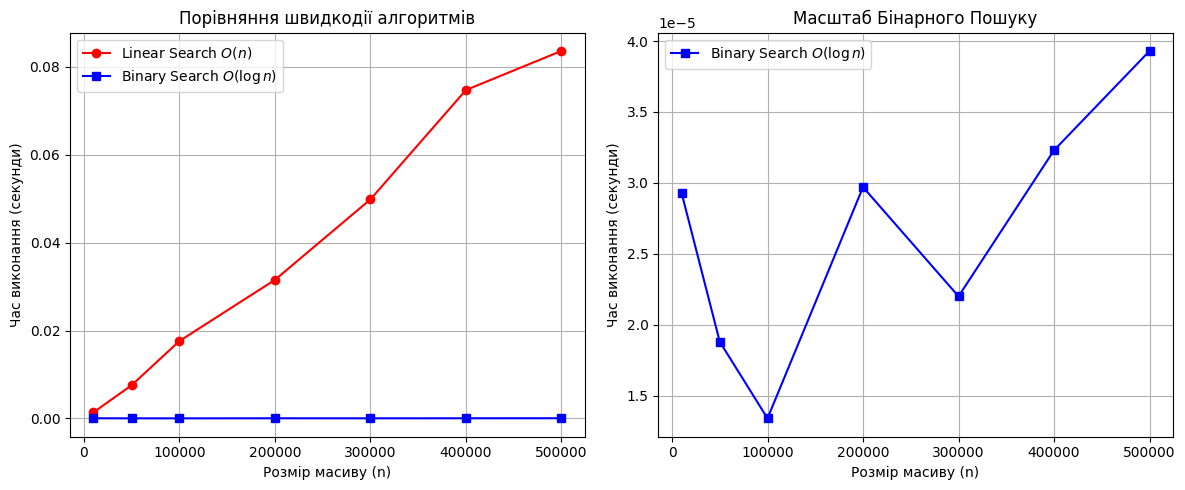

In [1]:
!pip install pandas
!pip install matplotlib
import time
import pandas as pd
import matplotlib.pyplot as plt

# --- Реалізація алгоритмів пошуку ---

def linear_search(a_list, x):
    """Лінійний пошук"""
    i, length = 0, len(a_list)
    while i < length and x != a_list[i]:
        i += 1
    return i if i < length else -1 

def bin_search(a_list, x, left, right):
    """Рекурсивний бінарний пошук"""
    if left > right or len(a_list) == 0:
        return -1
    middle = (left + right) // 2
    if a_list[middle] == x:
        return middle
    elif a_list[middle] < x:
        return bin_search(a_list, x, middle + 1, right)
    else:
        return bin_search(a_list, x, left, middle - 1)


# --- Функції для повернення DataFrame ---

def measure_linear_search(n_values):
    """Повертає DataFrame з полями ('n', 'time') для лінійного пошуку"""
    records = []
    for n in n_values:
        arr = list(range(n))
        search_item = -1 # Найгірший випадок (елемента немає)
        
        start = time.perf_counter()
        linear_search(arr, search_item)
        end = time.perf_counter()
        
        records.append({'n': n, 'time': end - start})
    return pd.DataFrame(records)

def measure_bin_search(n_values):
    """Повертає DataFrame з полями ('n', 'time') для бінарного пошуку"""
    records = []
    for n in n_values:
        arr = list(range(n)) # Вже відсортований масив
        search_item = -1 # Найгірший випадок
        
        start = time.perf_counter()
        bin_search(arr, search_item, 0, len(arr) - 1)
        end = time.perf_counter()
        
        records.append({'n': n, 'time': end - start})
    return pd.DataFrame(records)


# --- Обчислювальний експеримент ---

# Оптимальні розміри для демонстрації різниці (від 10 000 до 500 000)
n_list = [10000, 50000, 100000, 200000, 300000, 400000, 500000]

df_linear = measure_linear_search(n_list)
df_bin = measure_bin_search(n_list)

print("DataFrame для Linear Search:")
print(df_linear.to_string(index=False))
print("\nDataFrame для Binary Search:")
print(df_bin.to_string(index=False))


# --- Побудова графіків ---

plt.figure(figsize=(12, 5))

# Графік 1: Спільний масштаб
plt.subplot(1, 2, 1)
plt.plot(df_linear['n'], df_linear['time'], 'r-o', label='Linear Search $O(n)$')
plt.plot(df_bin['n'], df_bin['time'], 'b-s', label='Binary Search $O(\log n)$')
plt.xlabel('Розмір масиву (n)')
plt.ylabel('Час виконання (секунди)')
plt.title('Порівняння швидкодії алгоритмів')
plt.legend()
plt.grid(True)

# Графік 2: Окремий масштаб для бінарного пошуку
plt.subplot(1, 2, 2)
plt.plot(df_bin['n'], df_bin['time'], 'b-s', label='Binary Search $O(\log n)$')
plt.xlabel('Розмір масиву (n)')
plt.ylabel('Час виконання (секунди)')
plt.title('Масштаб Бінарного Пошуку')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Завдання 5

## Оцінити, який з двох алгоритмів є ефективнішим і в якому діапазоні розміру задачі

Бінарний пошук є значно ефективнішим за лінійний пошук для великих відсортованих масивів. Лінійний пошук має складність **O(n)**, тому час його виконання зростає пропорційно кількості елементів. Бінарний пошук має складність **O(log n)**, тому навіть для дуже великих масивів виконується швидко. Лінійний пошук доцільно використовувати для невеликих або невідсортованих масивів даних.

## Висновок: засвоїла варіанти реалізації алгоритмів пошуку засобами Python і методи оцінювання їх складності. 

# Контрольні питання

### 1. Сформулювати задачу пошуку.

Задача пошуку полягає у знаходженні елемента із заданим значенням у структурі даних або визначенні факту його відсутності.

### 2. Які критерії можна використовувати для оцінювання ефективності алгоритмів пошуку?

Основними критеріями оцінювання ефективності алгоритмів пошуку є часова складність, просторова складність, кількість виконаних порівнянь, а також поведінка алгоритму у найкращому, середньому та найгіршому випадках.

### 3. Що таке лінійний пошук і яка його асимптотична складність?

Лінійний пошук — це алгоритм, який послідовно перевіряє кожен елемент масиву до моменту знаходження потрібного значення або завершення списку.
Асимптотична складність лінійного пошуку становить **O(n)**.

#### 4. Що таке бінарний пошук і в чому полягає його головний принцип роботи?

Бінарний пошук — це алгоритм пошуку, який працює лише з відсортованими масивами. Його головний принцип полягає у послідовному поділі масиву навпіл і порівнянні шуканого елемента із середнім елементом.
Асимптотична складність становить **O(log n)**.

### 5. Які переваги і недоліки використання бінарного пошуку порівняно з лінійним?

Бінарний пошук має перевагу у вигляді високої швидкодії, оскільки його складність O(log n) значно менша за O(n) у лінійного пошуку.
Недоліком є те, що він працює лише з відсортованими масивами та потребує попередньої підготовки даних. Лінійний пошук, навпаки, простіший і може застосовуватись до невідсортованих даних.

### 6. Які ще алгоритми пошуку існують?

Окрім лінійного та бінарного пошуку існують також інтерполяційний пошук, стрибковий пошук, експоненціальний пошук, пошук Фібоначчі та пошук у хеш-таблицях.